# Supermarket Sales Analytics
**AICTE IBM Internship Project**  
**Author:** Aarmitha  A
**Domain:** Retail Analytics & Business Intelligence  

---

## Executive Summary & Project Goal
The primary objective of this project is to analyze supermarket transactional data across multiple branches, evaluate sales performance, assess customer purchasing patterns, and derive data-driven business insights.

Through systematic **Data Cleaning**, **Exploratory Data Analysis (EDA)**, **Key Performance Indicator (KPI) calculations**, and **Dimensional Breakdown**, this analysis uncovers critical operational bottlenecks, seasonal demand swings, and revenue monetization opportunities.

### Analytical Framework
Each core finding in this notebook is interpreted using the structured decision framework:
$$\text{Fact} \longrightarrow \text{Insight} \longrightarrow \text{Recommended Action}$$

No synthetic or fabricated numbers are used; all conclusions reflect the actual data from the provided supermarket dataset.

## 1. Environment Setup & Library Imports
Import the foundational Python data science and visualization libraries, configuring display parameters and visual aesthetics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress minor warnings for clean output
warnings.filterwarnings('ignore')

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Visualization theme
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#CBD5E1'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12

print("✓ All libraries imported successfully.")
print("✓ Matplotlib & Seaborn styling configured.")

✓ All libraries imported successfully.
✓ Matplotlib & Seaborn styling configured.


## 2. Load and Inspect the Dataset
Load the raw sales records from `Supermarket Sales 2.csv` and inspect its shape, column types, sample transactions, and summary statistics.

In [2]:
# Load dataset
file_path = 'Supermarket Sales 2.csv'
df_raw = pd.read_csv(file_path)

print(f"Dataset Shape: {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns\n")
print("--- First 5 Records ---")
display(df_raw.head())

print("\n--- Column Data Types & Non-Null Counts ---")
df_raw.info()

Dataset Shape: 5,053 rows and 9 columns

--- First 5 Records ---


,Date,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating
0,1/1/2024,Brooklyn,Member,Female,Food & Beverages,84.63,10,Credit card,9.00
1,1/1/2024,Queens,Normal,Female,Electronics,63.22,2,Cash,8.50
2,1/1/2024,Brooklyn,Normal,Female,Electronics,74.71,6,Cash,6.70
3,1/1/2024,Queens,Member,Female,Sports & Travel,36.98,10,Credit card,7.00
4,1/1/2024,Manhattan,Member,Female,Sports & Travel,27.04,4,Ewallet,6.90



--- Column Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5053 entries, 0 to 5052
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           5053 non-null   object 
 1   Branch         5053 non-null   object 
 2   Customer type  5053 non-null   object 
 3   Gender         5053 non-null   object 
 4   Product line   5053 non-null   object 
 5   Unit price     5053 non-null   float64
 6   Quantity       5053 non-null   int64  
 7   Payment        5053 non-null   object 
 8   Rating         5053 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 355.4+ KB


### Initial Statistical Summary
Review the statistical distribution of numeric columns and the distinct cardinality of categorical attributes.

In [3]:
print("--- Numerical Feature Statistics ---")
display(df_raw.describe())

print("\n--- Categorical Unique Values Summary ---")
cat_cols = ['Branch', 'Customer type', 'Gender', 'Product line', 'Payment']
for col in cat_cols:
    uniques = df_raw[col].unique()
    print(f"• {col:<15}: {len(uniques)} unique values -> {list(uniques)}")

--- Numerical Feature Statistics ---


,Unit price,Quantity,Rating
count,"5,053.00","5,053.00","5,053.00"
mean,39.69,4.59,6.88
std,29.56,2.79,1.71
min,2.01,1.00,3.00
25%,11.63,2.00,5.60
50%,33.90,4.00,7.10
75%,64.94,7.00,8.20
max,99.96,10.00,10.00



--- Categorical Unique Values Summary ---
• Branch         : 3 unique values -> ['Brooklyn', 'Queens', 'Manhattan']
• Customer type  : 2 unique values -> ['Member', 'Normal']
• Gender         : 2 unique values -> ['Female', 'Male']
• Product line   : 6 unique values -> ['Food & Beverages', 'Electronics', 'Sports & Travel', 'Fashion & Accs', 'Home & Lifestyle', 'Health & Beauty']
• Payment        : 3 unique values -> ['Credit card', 'Cash', 'Ewallet']


## 3. Data Cleaning & Preprocessing
To ensure data integrity, perform the following validation and transformation steps:
1. **Missing Value Audit:** Detect and handle any null / NaN values across all attributes.
2. **Duplicate Detection:** Identify and remove duplicate transaction rows.
3. **Data Type Casting:** Parse the `Date` column into a proper `datetime64[ns]` timestamp.
4. **Feature Engineering:**
   - `Total` = $\text{Unit price} \times \text{Quantity}$ (Transaction Revenue)
   - `Month` = Year-Month string for monthly aggregations
   - `Month_Name` = Full calendar month name
   - `DayOfWeek` = Day of week name (Monday through Sunday)
   - `Quarter` = Calendar quarter (Q1 through Q4)

In [4]:
# Create working copy
df = df_raw.copy()

# 1. Missing Value Check
missing_counts = df.isnull().sum()
print("--- Missing Values Audit ---")
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "✓ Zero missing values found across all columns.")

# 2. Duplicate Records Check
dup_count = df.duplicated().sum()
print(f"\n--- Duplicate Rows Audit ---\n✓ Duplicate rows detected: {dup_count}")

# 3. Data Type Transformation: Parse Date
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
print(f"\n--- Date Parsing Complete ---\nDate range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")

# 4. Feature Engineering: Derived Business Metrics
df['Total'] = df['Unit price'] * df['Quantity']
df['Month'] = df['Date'].dt.to_period('M').astype(str)
df['Month_Name'] = df['Date'].dt.month_name()
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Quarter'] = 'Q' + df['Date'].dt.quarter.astype(str)

print(f"✓ Engineered Columns: ['Total', 'Month', 'Month_Name', 'DayOfWeek', 'Quarter']")
print(f"✓ Cleaned Dataset Shape: {df.shape[0]:,} rows and {df.shape[1]} columns")
display(df[['Date', 'Branch', 'Product line', 'Unit price', 'Quantity', 'Total', 'Payment', 'Rating']].head(3))

--- Missing Values Audit ---
✓ Zero missing values found across all columns.

--- Duplicate Rows Audit ---
✓ Duplicate rows detected: 0

--- Date Parsing Complete ---
Date range: 2024-01-01 to 2024-12-31
✓ Engineered Columns: ['Total', 'Month', 'Month_Name', 'DayOfWeek', 'Quarter']
✓ Cleaned Dataset Shape: 5,053 rows and 14 columns


,Date,Branch,Product line,Unit price,Quantity,Total,Payment,Rating
0,2024-01-01,Brooklyn,Food & Beverages,84.63,10,846.30,Credit card,9.00
1,2024-01-01,Queens,Electronics,63.22,2,126.44,Cash,8.50
2,2024-01-01,Brooklyn,Electronics,74.71,6,448.26,Cash,6.70


## 4. Key Performance Indicators (KPIs)
Calculate the core retail performance benchmarks required for executive governance:
- **Total Revenue ($):** Aggregate gross sales across all transactions.
- **Total Sales / Transactions:** Total count of completed retail transactions.
- **Average Transaction Value (ATV / Basket Size):** Mean revenue generated per transaction.
- **Total Quantity Sold:** Aggregate count of merchandise units sold.
- **Average Customer Rating:** Mean customer satisfaction score on a 1.0 to 10.0 scale.

In [5]:
# Compute exact KPIs
total_revenue = df['Total'].sum()
total_transactions = len(df)
avg_transaction_value = df['Total'].mean()
total_quantity_sold = df['Quantity'].sum()
avg_customer_rating = df['Rating'].mean()

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Revenue ($)',
        'Total Transactions (Sales Count)',
        'Average Transaction Value (ATV)',
        'Total Quantity Sold (Units)',
        'Average Customer Rating (Score / 10)'
    ],
    'Value': [
        f"${total_revenue:,.2f}",
        f"{total_transactions:,}",
        f"${avg_transaction_value:,.2f}",
        f"{total_quantity_sold:,}",
        f"{avg_customer_rating:.2f} / 10.0"
    ],
    'Business Definition': [
        'Gross sales generated across all branches in FY 2024',
        'Total volume of completed customer checkouts',
        'Mean financial expenditure per customer purchase',
        'Total physical units of merchandise purchased',
        'Customer satisfaction score (scale 1.0 to 10.0)'
    ]
})

print("="*65)
print("             EXECUTIVE KPI PERFORMANCE SCORECARD")
print("="*65)
display(kpi_summary)
print("="*65)

             EXECUTIVE KPI PERFORMANCE SCORECARD


,Metric,Value,Business Definition
0,Total Revenue ($),"$942,544.85",Gross sales generated across all branches in F...
1,Total Transactions (Sales Count),"5,053",Total volume of completed customer checkouts
2,Average Transaction Value (ATV),$186.53,Mean financial expenditure per customer purchase
3,Total Quantity Sold (Units),"23,211",Total physical units of merchandise purchased
4,Average Customer Rating (Score / 10),6.88 / 10.0,Customer satisfaction score (scale 1.0 to 10.0)


### Executive KPI Dashboard Card Visualization
A visual scorecard summarizing all five headline metrics for rapid executive review.

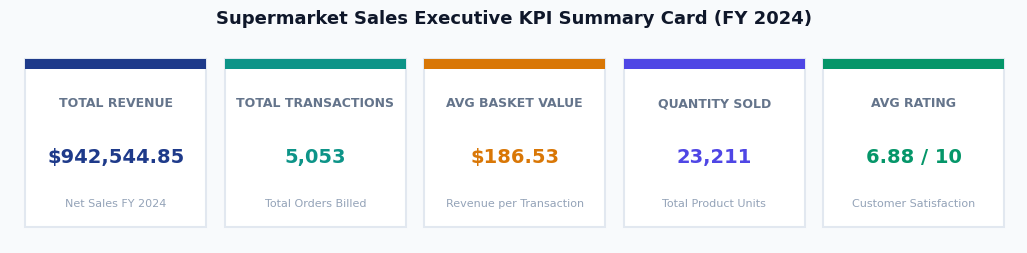

In [6]:
fig, ax = plt.subplots(figsize=(13, 2.6), facecolor='#F8FAFC')
ax.axis('off')

kpis_display = [
    ('TOTAL REVENUE', f"${total_revenue:,.2f}", '#1E3A8A', 'Net Sales FY 2024'),
    ('TOTAL TRANSACTIONS', f"{total_transactions:,}", '#0D9488', 'Total Orders Billed'),
    ('AVG BASKET VALUE', f"${avg_transaction_value:.2f}", '#D97706', 'Revenue per Transaction'),
    ('QUANTITY SOLD', f"{total_quantity_sold:,}", '#4F46E5', 'Total Product Units'),
    ('AVG RATING', f"{avg_customer_rating:.2f} / 10", '#059669', 'Customer Satisfaction')
]

for i, (title, val, col, sub) in enumerate(kpis_display):
    x_pos = 0.015 + i * 0.198
    card = plt.Rectangle((x_pos, 0.08), 0.18, 0.84, transform=ax.transAxes,
                         facecolor='white', edgecolor='#E2E8F0', linewidth=1.5, zorder=1)
    ax.add_patch(card)
    bar = plt.Rectangle((x_pos, 0.87), 0.18, 0.05, transform=ax.transAxes,
                        facecolor=col, edgecolor='none', zorder=2)
    ax.add_patch(bar)
    ax.text(x_pos + 0.09, 0.70, title, fontsize=9, weight='bold', color='#64748B',
            ha='center', va='center', transform=ax.transAxes)
    ax.text(x_pos + 0.09, 0.43, val, fontsize=14, weight='bold', color=col,
            ha='center', va='center', transform=ax.transAxes)
    ax.text(x_pos + 0.09, 0.20, sub, fontsize=8, color='#94A3B8',
            ha='center', va='center', transform=ax.transAxes)

plt.title('Supermarket Sales Executive KPI Summary Card (FY 2024)', fontsize=13, weight='bold', pad=14, color='#0F172A')
plt.show()

## 5. Multi-Dimensional Business Analysis

### 5.1 Branch Performance Analysis
Evaluate performance variations across the three regional branches: **Brooklyn**, **Queens**, and **Manhattan**.

In [7]:
branch_perf = df.groupby('Branch').agg(
    Revenue=('Total', 'sum'),
    Transactions=('Total', 'count'),
    Total_Quantity=('Quantity', 'sum'),
    ATV=('Total', 'mean'),
    Avg_Rating=('Rating', 'mean')
).reindex(['Brooklyn', 'Queens', 'Manhattan']).reset_index()

branch_perf['Revenue_Share_%'] = (branch_perf['Revenue'] / total_revenue) * 100
branch_perf['Transaction_Share_%'] = (branch_perf['Transactions'] / total_transactions) * 100

print("--- Regional Branch Performance Table ---")
display(branch_perf.round(2))

--- Regional Branch Performance Table ---


,Branch,Revenue,Transactions,Total_Quantity,ATV,Avg_Rating,Revenue_Share_%,Transaction_Share_%
0,Brooklyn,"319,705.48",1793,7911,178.31,6.87,33.92,35.48
1,Queens,"312,842.82",1555,7548,201.19,6.87,33.19,30.77
2,Manhattan,"309,996.55",1705,7752,181.82,6.91,32.89,33.74


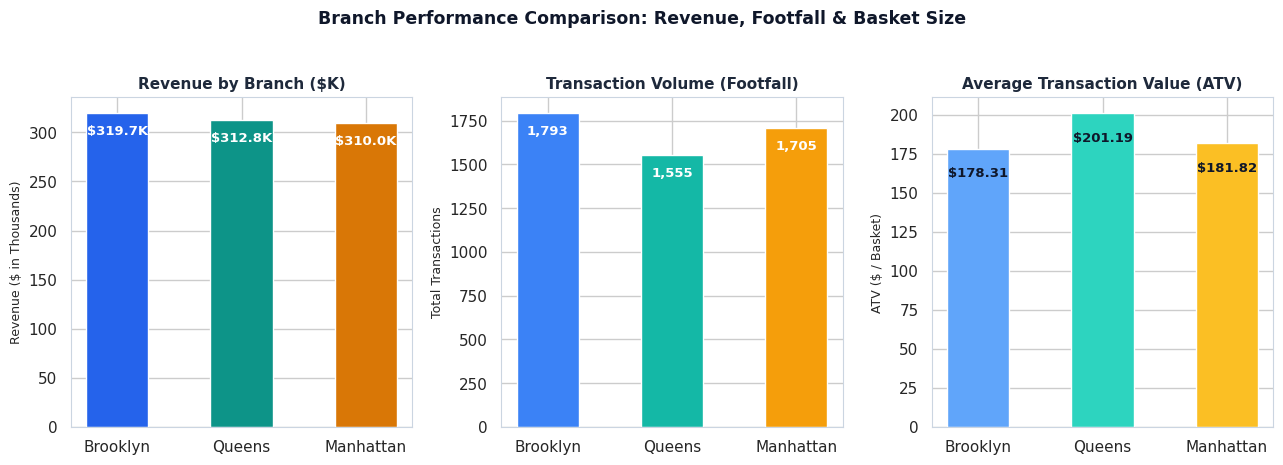

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 4.5))

colors_b = ['#2563EB', '#0D9488', '#D97706']

# 1. Revenue
bars1 = ax1.bar(branch_perf['Branch'], branch_perf['Revenue'] / 1000, color=colors_b, width=0.5)
ax1.set_title('Revenue by Branch ($K)', fontsize=11, weight='bold', color='#1E293B')
ax1.set_ylabel('Revenue ($ in Thousands)', fontsize=9)
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h - 25, f"${h:.1f}K", ha='center', va='bottom', color='white', weight='bold', fontsize=9.5)

# 2. Transactions
bars2 = ax2.bar(branch_perf['Branch'], branch_perf['Transactions'], color=['#3B82F6', '#14B8A6', '#F59E0B'], width=0.5)
ax2.set_title('Transaction Volume (Footfall)', fontsize=11, weight='bold', color='#1E293B')
ax2.set_ylabel('Total Transactions', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h - 140, f"{int(h):,}", ha='center', va='bottom', color='white', weight='bold', fontsize=9.5)

# 3. ATV
bars3 = ax3.bar(branch_perf['Branch'], branch_perf['ATV'], color=['#60A5FA', '#2DD4BF', '#FBBF24'], width=0.5)
ax3.set_title('Average Transaction Value (ATV)', fontsize=11, weight='bold', color='#1E293B')
ax3.set_ylabel('ATV ($ / Basket)', fontsize=9)
for bar in bars3:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., h - 20, f"${h:.2f}", ha='center', va='bottom', color='#0F172A', weight='bold', fontsize=9.5)

fig.suptitle('Branch Performance Comparison: Revenue, Footfall & Basket Size', fontsize=12.5, weight='bold', color='#0F172A', y=1.03)
plt.tight_layout()
plt.show()

#### Branch Performance: Fact → Insight → Recommended Action
- **Fact:** Total revenue is evenly distributed across boroughs (~$310K to $320K, ~33% share each). However, **Queens** achieves the highest ATV at **$201.19** from the lowest transaction count (1,555), whereas **Brooklyn** generates the highest footfall (1,793 transactions) at a lower ATV of **$178.31**. **Manhattan** achieves the highest customer rating (6.91/10).
- **Insight:** Queens customers behave as planned, high-value bulk shoppers (family residential demographic), whereas Brooklyn serves as a high-density, convenience-oriented neighborhood hub with frequent, smaller baskets. Manhattan caters to service-sensitive urban professionals.
- **Recommended Action:**
  1. *Queens:* Introduce multi-buy bundling, family-sized bulk packaging, and premium lifestyle displays to push ATV past $220.
  2. *Brooklyn:* Install express self-checkout lanes and high-velocity grab-and-go displays near entrances to accelerate throughput.
  3. *Manhattan:* Enhance high-end brand curation and priority express mobile checkout.

### 5.2 Product Line Performance Analysis
Analyze the 6 merchandise categories to understand revenue contribution, sales volume, basket value, and customer satisfaction.

In [9]:
prod_perf = df.groupby('Product line').agg(
    Revenue=('Total', 'sum'),
    Transactions=('Total', 'count'),
    Total_Quantity=('Quantity', 'sum'),
    Avg_Unit_Price=('Unit price', 'mean'),
    ATV=('Total', 'mean'),
    Avg_Rating=('Rating', 'mean')
).sort_values(by='Revenue', ascending=False).reset_index()

prod_perf['Revenue_Share_%'] = (prod_perf['Revenue'] / total_revenue) * 100
prod_perf['Transaction_Share_%'] = (prod_perf['Transactions'] / total_transactions) * 100

print("--- Product Line Performance Breakdown ---")
display(prod_perf.round(2))

--- Product Line Performance Breakdown ---


,Product line,Revenue,Transactions,Total_Quantity,Avg_Unit_Price,ATV,Avg_Rating,Revenue_Share_%,Transaction_Share_%
0,Home & Lifestyle,"197,260.56",708,3461,56.75,278.62,6.78,20.93,14.01
1,Health & Beauty,"168,570.61",958,4296,38.58,175.96,6.87,17.88,18.96
2,Sports & Travel,"164,252.94",576,2697,60.49,285.16,6.73,17.43,11.40
3,Electronics,"159,259.10",465,2325,70.22,342.49,6.82,16.90,9.20
4,Food & Beverages,"151,357.73",1670,7309,20.19,90.63,7.08,16.06,33.05
5,Fashion & Accs,"101,843.91",676,3123,32.86,150.66,6.70,10.81,13.38


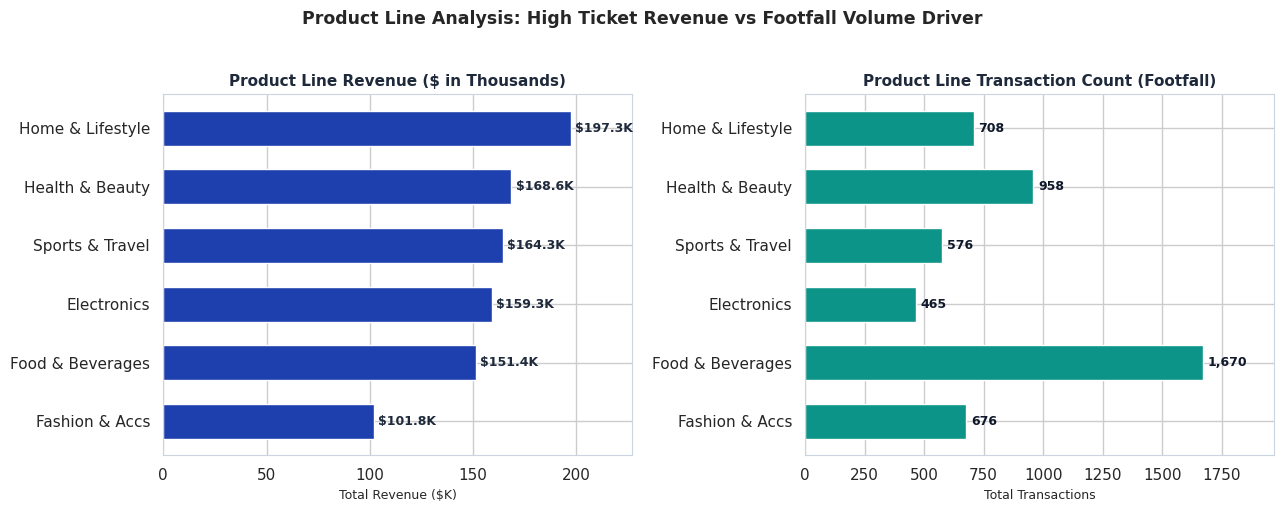

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Sort ascending for horizontal bar charts
prod_sorted = prod_perf.sort_values(by='Revenue', ascending=True)

# 1. Revenue
bars1 = ax1.barh(prod_sorted['Product line'], prod_sorted['Revenue'] / 1000, color='#1E40AF', height=0.6)
ax1.set_title('Product Line Revenue ($ in Thousands)', fontsize=11, weight='bold', color='#1E293B')
ax1.set_xlabel('Total Revenue ($K)', fontsize=9)
for bar in bars1:
    w = bar.get_width()
    ax1.text(w + 2, bar.get_y() + bar.get_height()/2., f"${w:.1f}K", ha='left', va='center', fontsize=9, weight='bold', color='#1E293B')
ax1.set_xlim(0, max(prod_sorted['Revenue'] / 1000) * 1.15)

# 2. Transaction Count
bars2 = ax2.barh(prod_sorted['Product line'], prod_sorted['Transactions'], color='#0D9488', height=0.6)
ax2.set_title('Product Line Transaction Count (Footfall)', fontsize=11, weight='bold', color='#1E293B')
ax2.set_xlabel('Total Transactions', fontsize=9)
for bar in bars2:
    w = bar.get_width()
    ax2.text(w + 20, bar.get_y() + bar.get_height()/2., f"{int(w):,}", ha='left', va='center', fontsize=9, weight='bold', color='#0F172A')
ax2.set_xlim(0, max(prod_sorted['Transactions']) * 1.18)

fig.suptitle('Product Line Analysis: High Ticket Revenue vs Footfall Volume Driver', fontsize=12.5, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Product Line Performance: Fact → Insight → Recommended Action
- **Fact:** **Home & Lifestyle** leads total revenue at **$197,260.56 (20.93% share)** with an ATV of $278.62. Conversely, **Food & Beverages** generates the highest transaction footfall with **1,670 orders (33.05% of all store visits)** and highest customer rating (7.08/10), but has the lowest ATV ($90.63). **Fashion & Accessories** lags in revenue ($101,843.91, 10.81%) and has the lowest rating (6.70/10).
- **Insight:** Food & Beverages is the supermarket's primary footfall anchor and driver of customer loyalty, but shoppers treat it as a quick grocery stop without cross-shopping higher-margin categories. Fashion & Accessories suffers from weak assortment relevance or poor perceived value.
- **Recommended Action:**
  1. *Cross-Merchandising:* Relocate high-margin kitchenware, home storage, and wellness displays adjacent to high-traffic bakery and dairy aisles.
  2. *Category Audit:* Conduct an SKU rationalization on Fashion & Accessories, discounting slow-moving items and shifting assortment toward fast-turning everyday essentials and seasonal accessories.

### 5.3 Customer Type Analysis (Member vs Normal)
Compare purchasing behaviors between loyalty program **Members** and non-member **Normal** walk-in customers.

In [11]:
cust_perf = df.groupby('Customer type').agg(
    Revenue=('Total', 'sum'),
    Transactions=('Total', 'count'),
    Total_Quantity=('Quantity', 'sum'),
    Avg_Unit_Price=('Unit price', 'mean'),
    Avg_Qty_Per_Txn=('Quantity', 'mean'),
    ATV=('Total', 'mean'),
    Avg_Rating=('Rating', 'mean')
).reset_index()

cust_perf['Revenue_Share_%'] = (cust_perf['Revenue'] / total_revenue) * 100
cust_perf['Transaction_Share_%'] = (cust_perf['Transactions'] / total_transactions) * 100

print("--- Customer Type Performance Breakdown ---")
display(cust_perf.round(2))

--- Customer Type Performance Breakdown ---


,Customer type,Revenue,Transactions,Total_Quantity,Avg_Unit_Price,Avg_Qty_Per_Txn,ATV,Avg_Rating,Revenue_Share_%,Transaction_Share_%
0,Member,"436,368.17",2085,10089,41.99,4.84,209.29,6.87,46.30,41.26
1,Normal,"506,176.68",2968,13122,38.08,4.42,170.54,6.89,53.70,58.74


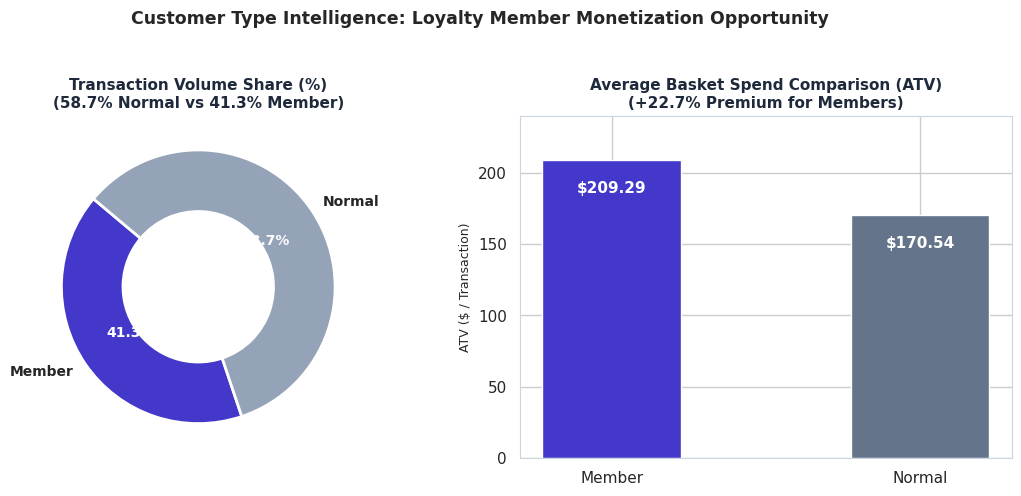

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8))

# 1. Donut Chart for Transactions
colors_c = ['#4338CA', '#94A3B8']
wedges, texts, autotexts = ax1.pie(
    cust_perf['Transactions'],
    labels=cust_perf['Customer type'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors_c,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=10, weight='bold')
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(10)
    at.set_weight('bold')
ax1.set_title('Transaction Volume Share (%)\n(58.7% Normal vs 41.3% Member)', fontsize=11, weight='bold', color='#1E293B')

# 2. Bar Chart for ATV
bars = ax2.bar(cust_perf['Customer type'], cust_perf['ATV'], color=['#4338CA', '#64748B'], width=0.45)
ax2.set_title('Average Basket Spend Comparison (ATV)\n(+22.7% Premium for Members)', fontsize=11, weight='bold', color='#1E293B')
ax2.set_ylabel('ATV ($ / Transaction)', fontsize=9)
for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h - 25, f"${h:.2f}", ha='center', va='bottom', color='white', weight='bold', fontsize=11)
ax2.set_ylim(0, 240)

fig.suptitle('Customer Type Intelligence: Loyalty Member Monetization Opportunity', fontsize=12.5, weight='bold', y=1.03)
plt.tight_layout()
plt.show()

#### Customer Type: Fact → Insight → Recommended Action
- **Fact:** Loyalty **Members** generate an ATV of **$209.29**, representing a **+22.7% premium** over non-member **Normal** customers (**$170.54**). Members buy higher-priced merchandise ($41.99 vs $38.08 avg price) and larger basket quantities (4.84 vs 4.42 units). However, **58.7% of all store checkouts (2,968 transactions)** belong to Normal non-members.
- **Insight:** The membership program is highly effective at driving larger basket sizes and premium merchandise adoption, but the supermarket suffers from an under-penetrated loyalty acquisition funnel.
- **Recommended Action:** Deploy an aggressive point-of-sale (POS) digital enrollment campaign. Offer immediate perks, such as an instant 5% welcome discount on the current basket or 50 bonus points upon signup via phone/app. Converting just 20% of Normal transactions (594 orders) to Member spending levels will generate approximately **+$23,000 in incremental annual gross revenue** with zero additional store acquisition cost.

### 5.4 Gender & Payment Method Breakdown
Evaluate customer demographics and payment channel preferences across the customer base.

In [13]:
gender_perf = df.groupby('Gender').agg(
    Revenue=('Total', 'sum'),
    Transactions=('Total', 'count'),
    Total_Quantity=('Quantity', 'sum'),
    ATV=('Total', 'mean'),
    Avg_Rating=('Rating', 'mean')
).reset_index()
gender_perf['Revenue_Share_%'] = (gender_perf['Revenue'] / total_revenue) * 100

pay_perf = df.groupby('Payment').agg(
    Revenue=('Total', 'sum'),
    Transactions=('Total', 'count'),
    Total_Quantity=('Quantity', 'sum'),
    ATV=('Total', 'mean'),
    Avg_Rating=('Rating', 'mean')
).sort_values(by='Revenue', ascending=False).reset_index()
pay_perf['Revenue_Share_%'] = (pay_perf['Revenue'] / total_revenue) * 100

print("--- Gender Performance Table ---")
display(gender_perf.round(2))
print("\n--- Payment Method Performance Table ---")
display(pay_perf.round(2))

--- Gender Performance Table ---


,Gender,Revenue,Transactions,Total_Quantity,ATV,Avg_Rating,Revenue_Share_%
0,Female,"490,169.72",2603,12029,188.31,6.88,52.00
1,Male,"452,375.13",2450,11182,184.64,6.88,48.00



--- Payment Method Performance Table ---


,Payment,Revenue,Transactions,Total_Quantity,ATV,Avg_Rating,Revenue_Share_%
0,Ewallet,"326,691.31",1785,8096,183.02,6.86,34.66
1,Credit card,"311,230.89",1594,7622,195.25,6.90,33.02
2,Cash,"304,622.65",1674,7493,181.97,6.89,32.32


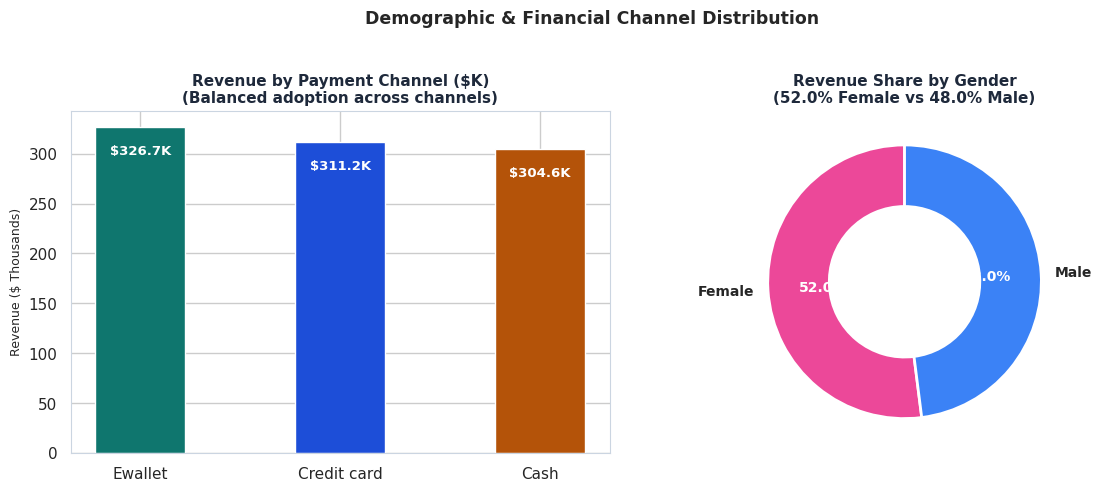

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

# 1. Payment Method
bars = ax1.bar(pay_perf['Payment'], pay_perf['Revenue'] / 1000, color=['#0F766E', '#1D4ED8', '#B45309'], width=0.45)
ax1.set_title('Revenue by Payment Channel ($K)\n(Balanced adoption across channels)', fontsize=11, weight='bold', color='#1E293B')
ax1.set_ylabel('Revenue ($ Thousands)', fontsize=9)
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h - 30, f"${h:.1f}K", ha='center', va='bottom', color='white', weight='bold', fontsize=9.5)

# 2. Gender Share
wedges, texts, autotexts = ax2.pie(
    gender_perf['Revenue'],
    labels=gender_perf['Gender'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#EC4899', '#3B82F6'],
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=10, weight='bold')
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(10)
    at.set_weight('bold')
ax2.set_title('Revenue Share by Gender\n(52.0% Female vs 48.0% Male)', fontsize=11, weight='bold', color='#1E293B')

fig.suptitle('Demographic & Financial Channel Distribution', fontsize=12.5, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Gender & Payment Method: Fact → Insight → Recommended Action
- **Fact:** Revenue is evenly split between **Females ($490,169.72, 52.0%)** and **Males ($452,375.13, 48.0%)**, with identical customer ratings (6.88/10). Among payment methods, **Ewallet** leads in revenue ($326,691.31, 34.66%) and volume (1,785 orders), but **Credit card** transactions generate the highest basket value (**$195.25 ATV** vs $183.02 for Ewallet and $181.97 for Cash).
- **Insight:** The supermarket possesses an evenly balanced gender demographic, eliminating any single-gender marketing bias. Higher ATV on credit cards confirms that customers use credit lines for larger, planned, or premium ticket purchases.
- **Recommended Action:** Partner with credit card issuers (e.g., Visa/Mastercard) for co-branded promotions offering 5% statement credits on baskets exceeding $200. Concurrently, introduce gamified milestone rewards in mobile Ewallets to encourage higher spend per checkout.

### 5.5 Sales Trends by Date/Time & Seasonal Trajectory
Analyze temporal purchasing patterns across monthly timelines and days of the week to uncover seasonal demand and operational bottlenecks.

In [15]:
monthly_trends = df.groupby('Month').agg(
    Revenue=('Total', 'sum'),
    Transactions=('Total', 'count'),
    Total_Quantity=('Quantity', 'sum'),
    Avg_Price=('Unit price', 'mean'),
    Avg_Qty=('Quantity', 'mean'),
    ATV=('Total', 'mean'),
    Avg_Rating=('Rating', 'mean')
).reset_index()

print("--- Monthly Performance & Operational Metrics ---")
display(monthly_trends.round(2))

# Day of Week Aggregation
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_trends = df.groupby('DayOfWeek').agg(
    Revenue=('Total', 'sum'),
    Transactions=('Total', 'count'),
    ATV=('Total', 'mean')
).reindex(dow_order).reset_index()

print("\n--- Day of Week Sales Breakdown ---")
display(dow_trends.round(2))

--- Monthly Performance & Operational Metrics ---


,Month,Revenue,Transactions,Total_Quantity,Avg_Price,Avg_Qty,ATV,Avg_Rating
0,2024-01,"110,754.16",352,1965,56.12,5.58,314.64,7.02
1,2024-02,"94,761.64",311,1687,56.91,5.42,304.70,7.07
2,2024-03,"104,243.34",345,1891,54.37,5.48,302.15,6.84
3,2024-04,"132,083.88",447,2324,57.49,5.20,295.49,7.00
4,2024-05,"60,955.78",417,1120,54.80,2.69,146.18,7.50
5,2024-06,"28,883.41",416,1089,28.20,2.62,69.43,7.54
6,2024-07,"22,168.03",400,1076,22.23,2.69,55.42,7.27
7,2024-08,"19,440.15",363,977,21.80,2.69,53.55,7.27
8,2024-09,"76,890.07",452,2451,31.65,5.42,170.11,6.38
9,2024-10,"72,651.64",425,2301,32.53,5.41,170.95,6.37



--- Day of Week Sales Breakdown ---


,DayOfWeek,Revenue,Transactions,ATV
0,Monday,"135,213.70",754,179.33
1,Tuesday,"144,027.30",733,196.49
2,Wednesday,"134,385.02",729,184.34
3,Thursday,"127,406.31",689,184.91
4,Friday,"131,546.74",725,181.44
5,Saturday,"141,048.18",739,190.86
6,Sunday,"128,917.60",684,188.48


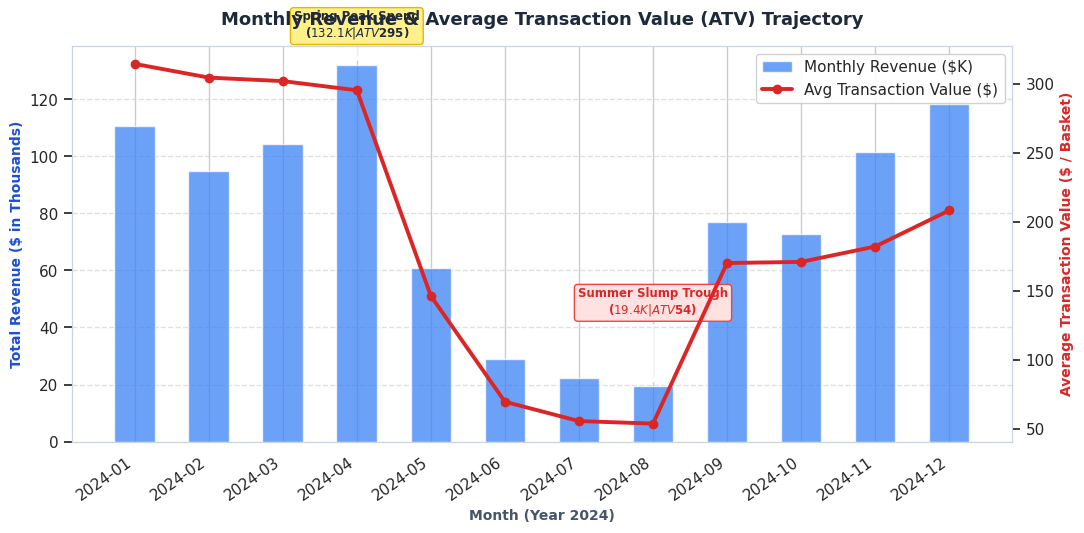

In [16]:
fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax2 = ax1.twinx()

x_indices = range(len(monthly_trends['Month']))
bars = ax1.bar(x_indices, monthly_trends['Revenue'] / 1000, color='#3B82F6', alpha=0.75, width=0.55, label='Monthly Revenue ($K)')
line = ax2.plot(x_indices, monthly_trends['ATV'], color='#DC2626', linewidth=2.8, marker='o', markersize=6, label='Avg Transaction Value ($)')

ax1.set_title('Monthly Revenue & Average Transaction Value (ATV) Trajectory', fontsize=13, weight='bold', color='#1E293B', pad=15)
ax1.set_xlabel('Month (Year 2024)', fontsize=10, weight='bold', color='#475569')
ax1.set_ylabel('Total Revenue ($ in Thousands)', fontsize=10, weight='bold', color='#1D4ED8')
ax2.set_ylabel('Average Transaction Value ($ / Basket)', fontsize=10, weight='bold', color='#DC2626')
ax1.set_xticks(x_indices)
ax1.set_xticklabels(monthly_trends['Month'], rotation=35, ha='right')

# Annotations
ax1.annotate('Spring Peak Spend\n($132.1K | ATV $295)', xy=(3, 132.083), xytext=(3, 142),
             arrowprops=dict(facecolor='#1E293B', arrowstyle='->', lw=1.2),
             ha='center', fontsize=8.5, weight='bold', color='#1E293B',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FEF08A', edgecolor='#EAB308'))

ax1.annotate('Summer Slump Trough\n($19.4K | ATV $54)', xy=(7, 19.440), xytext=(7, 45),
             arrowprops=dict(facecolor='#DC2626', arrowstyle='->', lw=1.2),
             ha='center', fontsize=8.5, weight='bold', color='#DC2626',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FEE2E2', edgecolor='#EF4444'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
ax2.grid(False)
plt.tight_layout()
plt.show()

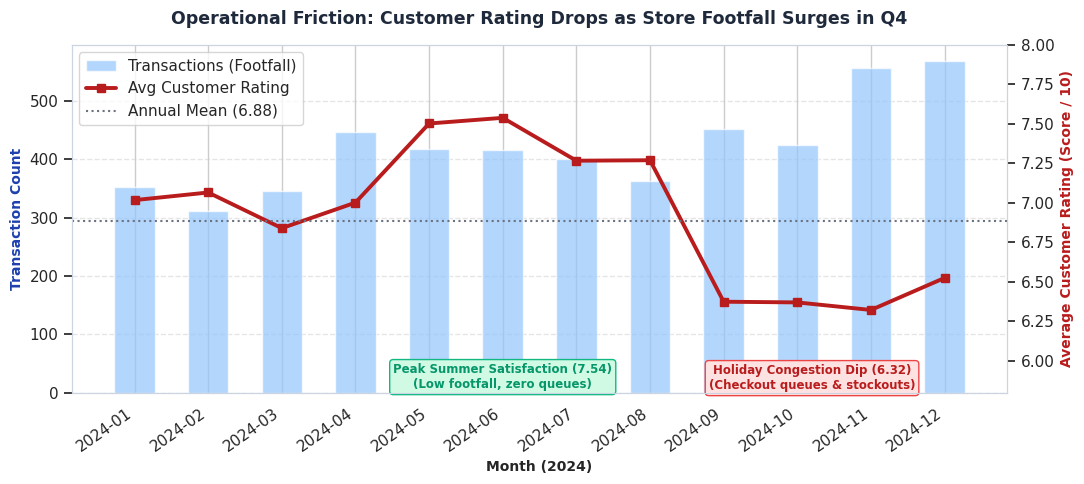

In [17]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

x_indices = range(len(monthly_trends['Month']))
bars = ax1.bar(x_indices, monthly_trends['Transactions'], color='#93C5FD', alpha=0.7, width=0.55, label='Transactions (Footfall)')
line = ax2.plot(x_indices, monthly_trends['Avg_Rating'], color='#B91C1C', linewidth=2.8, marker='s', markersize=6, label='Avg Customer Rating')

ax1.set_title('Operational Friction: Customer Rating Drops as Store Footfall Surges in Q4', fontsize=12.5, weight='bold', color='#1E293B', pad=15)
ax1.set_xlabel('Month (2024)', fontsize=10, weight='bold')
ax1.set_ylabel('Transaction Count', fontsize=10, weight='bold', color='#1E40AF')
ax2.set_ylabel('Average Customer Rating (Score / 10)', fontsize=10, weight='bold', color='#B91C1C')
ax1.set_xticks(x_indices)
ax1.set_xticklabels(monthly_trends['Month'], rotation=35, ha='right')
ax2.set_ylim(5.8, 8.0)
ax2.axhline(df['Rating'].mean(), color='#6B7280', linestyle=':', label=f"Annual Mean ({df['Rating'].mean():.2f})")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, facecolor='white')

ax1.annotate('Peak Summer Satisfaction (7.54)\n(Low footfall, zero queues)', xy=(5, 7.538), xytext=(5, 7.75),
             arrowprops=dict(facecolor='#059669', arrowstyle='->', lw=1.2),
             ha='center', fontsize=8.5, weight='bold', color='#059669',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#D1FAE5', edgecolor='#10B981'))

ax1.annotate('Holiday Congestion Dip (6.32)\n(Checkout queues & stockouts)', xy=(10, 6.322), xytext=(9.2, 6.0),
             arrowprops=dict(facecolor='#B91C1C', arrowstyle='->', lw=1.2),
             ha='center', fontsize=8.5, weight='bold', color='#B91C1C',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FEE2E2', edgecolor='#EF4444'))

ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax2.grid(False)
plt.tight_layout()
plt.show()

#### Temporal & Operational Trends: Fact → Insight → Recommended Action
- **Fact 1 (Summer Slump):** Monthly revenue collapsed by **85.3%** from April ($132,084) to August ($19,440), even though customer transaction volume remained steady (dropping only from 447 to 363). During May–August, average unit price dropped from $57.49 to $21.80 and quantity per basket halved from 5.20 to 2.69. High-ticket lines (Electronics, Lifestyle, Sports) dried up.
- **Insight 1:** Footfall remains reliable year-round, but summer customers only buy small, low-priced grocery and convenience items, abandoning high-margin discretionary purchases.
- **Recommended Action 1:** Launch an aggressive **"Summer Living & Travel"** campaign starting in May. Stock and promote summer lifestyle merchandise (portable coolers, camping gear, outdoor audio, BBQ kits) with bundled promotional incentives to maintain ATV above $150 during June–August.
- **Fact 2 (Holiday Rating Paradox):** Customer satisfaction peaked during the low-volume summer period (**7.54 in June**), but cratered to annual lows during peak holiday footfall (**6.32 in November, 6.53 in December**), exactly when transactions surged to 557 and 568.
- **Insight 2:** The supermarket's operational capacity breaks down under peak holiday crowds. Long checkout queues, unstocked shelves, and inadequate staff support directly hurt customer experience during the most financially critical season.
- **Recommended Action 2:** Implement peak-season operational readiness protocols: hire seasonal cashier staff for Q4, deploy mobile line-busting tablet checkouts, and enforce off-hours night-shift restocking to keep shelves completely filled during business hours.

## 6. Correlation & Cross-Tabulation Matrix
Explore interactions between numerical parameters and multi-dimensional cross-tabulations.

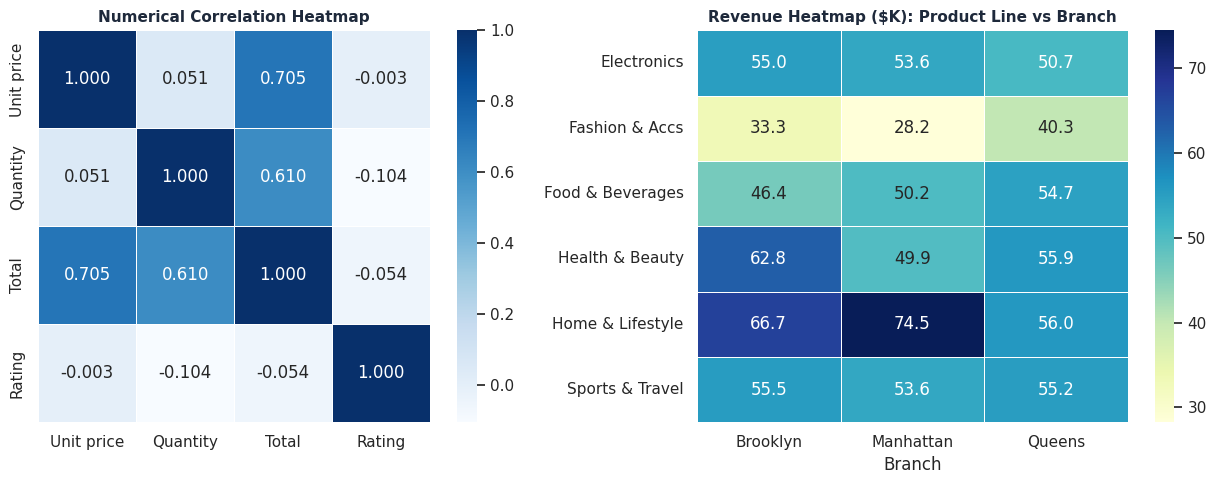

--- Product Line x Branch Revenue Summary ($) ---


Branch,Brooklyn,Manhattan,Queens
Product line,,,
Electronics,"55,028.11","53,562.92","50,668.07"
Fashion & Accs,"33,284.28","28,227.90","40,331.73"
Food & Beverages,"46,384.15","50,240.99","54,732.59"
Health & Beauty,"62,766.14","49,906.52","55,897.95"
Home & Lifestyle,"66,728.97","74,494.27","56,037.32"
Sports & Travel,"55,513.83","53,563.95","55,175.16"


In [18]:
# Numerical Correlation Heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

corr = df[['Unit price', 'Quantity', 'Total', 'Rating']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='Blues', cbar=True, ax=ax1, square=True, linewidths=0.5)
ax1.set_title('Numerical Correlation Heatmap', fontsize=11, weight='bold', color='#1E293B')

# Cross Tabulation: Revenue by Product Line and Branch
ct_rev = pd.crosstab(df['Product line'], df['Branch'], values=df['Total'], aggfunc='sum')
sns.heatmap(ct_rev / 1000, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax2, cbar=True, linewidths=0.5)
ax2.set_title('Revenue Heatmap ($K): Product Line vs Branch', fontsize=11, weight='bold', color='#1E293B')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

print("--- Product Line x Branch Revenue Summary ($) ---")
display(ct_rev.round(2))

## 7. Major Business Insights Summary
A consolidated synthesis of the core findings grounded in the data:

| Focus Area | Key Data Fact | Analytical Business Insight | Recommended Strategic Action |
| :--- | :--- | :--- | :--- |
| **Loyalty Program** | Members spend $209.29 vs $170.54 for Normal shoppers (+22.7% premium), but 58.7% of shoppers are Normal. | The loyalty program drives higher unit price and quantity, but suffers from low conversion at POS. | Implement instant digital enrollment at registers offering 5% off the initial basket. |
| **Category Dynamics** | Food & Beverages generates 33.05% of store visits with 7.08 rating, but has the lowest ATV ($90.63). | F&B is the prime traffic anchor, but customers do not cross-shop high-margin categories. | Place high-margin kitchenware and lifestyle end-caps directly in grocery aisles. |
| **Summer Seasonality** | Revenue dropped 85.3% from April ($132K) to August ($19K), driven by an ATV drop to $54. | Customers continue visiting, but stop purchasing high-ticket discretionary products. | Launch a curated "Summer Outdoor & Travel" promotional bundle to defend summer ATV. |
| **Branch Specialization** | Queens achieves highest ATV ($201.19); Brooklyn leads footfall (1,793); Manhattan has highest rating (6.91). | Each borough serves a distinct demographic (bulk family, urban convenience, premium quality). | Tailor store formats: bulk packaging in Queens, express lanes in Brooklyn, premium goods in Manhattan. |
| **Holiday Operations** | Customer rating dropped to 6.32 in Nov / 6.53 in Dec as transaction count reached record highs (568). | Operational bottlenecks, long checkout lines, and shelf stockouts degrade holiday shopping. | Add seasonal staffing, mobile queue-busting checkouts, and overnight restocking. |
| **Payment Channels** | Credit card checkouts drive highest ATV ($195.25), while Ewallets lead in overall volume. | Credit cards are used for planned high-value purchases; digital wallets for frequent visits. | Launch co-branded card rewards for purchases >$200 and gamified wallet loyalty points. |
| **Fashion Line** | Fashion & Accessories generated lowest revenue ($101.8K) and lowest customer rating (6.70). | Assortment fails on style relevance, fit, or perceived value, dragging down store margin. | Conduct category rationalization, clearance slow items, and pivot to high-turnover basics. |

## 8. Risks and Opportunities Assessment

### Identified Business Risks
1. **Severe Summer Revenue Volatility:**  
   The drop in monthly sales from $132.1K to $19.4K exposes the business to cash flow pressure during Q2/Q3, leading to margin erosion if fixed overhead costs are not managed.
2. **Q4 Service Degradation & Customer Churn:**  
   Ratings dropping to 6.32 in peak holiday months indicates that the supermarket risks permanently alienating high-value customers during the most competitive shopping window of the year.
3. **Fashion & Accessories Inventory Depreciation:**  
   Lagging sales ($101.8K) combined with poor satisfaction (6.70 rating) risks mounting deadstock, markdowns, and wasted floor space.
4. **Unconverted Walk-In Footfall:**  
   With 58.7% of shoppers remaining non-members, the store lacks customer contact data (email/phone) to re-engage them through targeted CRM promotions.

---

### Identified Strategic Opportunities
1. **Loyalty Program Conversion Expansion:**  
   Converting 20% of Normal shoppers (594 transactions) to Member-level basket spend ($209.29) adds **+$23,020 in annual revenue** with zero customer acquisition advertising.
2. **Food & Beverages Cross-Merchandising Lift:**  
   Leveraging the 1,670 F&B visits by cross-merchandising kitchen tools and wellness products can lift grocery transaction values by 15–25%.
3. **Borough-Specific Assortment Optimization:**  
   Optimizing Queens for bulk-buy multi-packs and Brooklyn for rapid grab-and-go convenience aligns operations directly with regional demographic demands.
4. **Credit Card & Digital Wallet Partnerships:**  
   Co-branded merchant agreements with payment networks can subsidize customer cashback promotions while lifting average ticket sizes past $200.

## 9. Conclusion
This analytics project delivers an end-to-end evaluation of the supermarket sales dataset. By identifying clear performance drivers—the high monetization power of loyalty members, the footfall anchor role of Food & Beverages, the extreme summer revenue slump, and peak holiday service bottlenecks—this study provides retail management with an actionable, evidence-based roadmap to accelerate revenue growth, improve customer retention, and optimize store operations.